# 06 — Cluster-Based Inverse Design

**Problem**: LHS over full 17D composition space produces impossible alloy
combinations. Tree models extrapolate poorly.

**Solution**: K-means clustering on composition -> metallurgical families.
Per-cluster LHS (N=5000) within data-driven bounds -> Champion -> Pareto.

**Constraints**:
- Sc <= 0.3%, Fe <= 0.5% (domain-knowledge caps)
- Tage >= 100C (artificial ageing only)
- Al >= 85%, Tage < Tsol - 30, UTS >= YS, YS >= 250 MPa
- Best Balance via Euclidean distance to utopia (max YS, UTS, El)

**Reference**: Bhat et al. (2024), *Metals* 14(2), 239.

**Input**: , 
**Output**: , 

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from featurize_metal import featurize_metal_all
warnings.filterwarnings('ignore')

MODEL_DIR = os.path.join('..', 'best_models')
DATA_DIR = os.path.join('..', 'data')
OPT_DIR = os.path.join('..', 'optimization_results')
FIGURE_DIR = os.path.join('..', 'figure')
os.makedirs(OPT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
SAVE_DPI = 600

TARGET_COLS = ['YS', 'UTS', 'El']
ELEMENTS = ['Si','Fe','Cu','Mn','Mg','Cr','Zn','V','Ti','Zr','Li','Ni','Be','Sc']
PROCESS_COLS = ['Tsol','Tage','tage']
ALL_VARS = ELEMENTS + PROCESS_COLS
RAW_COLS_ALL = ELEMENTS + PROCESS_COLS
N_LHS = 5000

champion = {}
for t in TARGET_COLS:
    with open(os.path.join(MODEL_DIR, f'model_{t}.pkl'), 'rb') as f:
        champion[t] = pickle.load(f)
    r2 = champion[t].get('repeated_split_r2_mean', float('nan'))
    print(f'{t}: {champion[t]["model_name"]} (R2={r2:.4f})')

YS: ExtraTrees (R2=0.9032)
UTS: ExtraTrees (R2=0.8914)
El: LightGBM (R2=0.7479)


## Step 1 — K-Means Clustering

In [2]:
df_all = pd.read_csv(os.path.join(DATA_DIR, 'metal_cleaned.csv'))
X_comp = df_all[ELEMENTS].fillna(0).values
X_sc = StandardScaler().fit_transform(X_comp)

print('=== K Selection by Silhouette Score ===')
best_k, best_sil = 3, 0
for kt in range(3, 8):
    kmt = KMeans(n_clusters=kt, random_state=42, n_init=10)
    lb = kmt.fit_predict(X_sc)
    sil = silhouette_score(X_sc, lb)
    sizes = [(lb==c).sum() for c in range(kt)]
    print(f'  K={kt}: silhouette={sil:.3f}, min_size={min(sizes)}, sizes={sizes}')
    if sil > best_sil and min(sizes) >= 10:
        best_sil, best_k = sil, kt

K = best_k
print(f'\nSelected K={K} (silhouette={best_sil:.3f})')

km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_all['cluster'] = km.fit_predict(X_sc)

clusters = {}
print(f'\n=== Cluster Summary (K={K}) ===')
for c in range(K):
    mask = df_all['cluster'] == c
    cdf = df_all[mask]
    sig = [e for e in ELEMENTS if cdf[e].mean() > 0.005]
    label = '+'.join(sig[:3]) if sig else f'C{c+1}'
    clusters[c] = {'label': label, 'n': mask.sum(), 'data': cdf, 'id': c+1}
    print(f'  C{c+1}: {mask.sum():>3} samples, YS={cdf["YS"].mean():.0f} MPa')
    print(f'       sig: {sig}')

=== K Selection by Silhouette Score ===
  K=3: silhouette=0.271, min_size=99, sizes=[np.int64(185), np.int64(210), np.int64(99)]
  K=4: silhouette=0.329, min_size=41, sizes=[np.int64(185), np.int64(168), np.int64(100), np.int64(41)]
  K=5: silhouette=0.362, min_size=40, sizes=[np.int64(53), np.int64(168), np.int64(99), np.int64(40), np.int64(134)]
  K=6: silhouette=0.388, min_size=9, sizes=[np.int64(53), np.int64(42), np.int64(134), np.int64(157), np.int64(99), np.int64(9)]
  K=7: silhouette=0.387, min_size=6, sizes=[np.int64(60), np.int64(157), np.int64(100), np.int64(37), np.int64(6), np.int64(125), np.int64(9)]

Selected K=5 (silhouette=0.362)

=== Cluster Summary (K=5) ===
  C1:  53 samples, YS=515 MPa
       sig: ['Cu', 'Mg', 'Zn']
  C2: 168 samples, YS=308 MPa
       sig: ['Si', 'Cu', 'Mg']
  C3:  99 samples, YS=339 MPa
       sig: ['Cu', 'Mg', 'Zn', 'Li']
  C4:  40 samples, YS=359 MPa
       sig: ['Si', 'Cu', 'Mg']
  C5: 134 samples, YS=491 MPa
       sig: ['Cu', 'Mg', 'Zn']


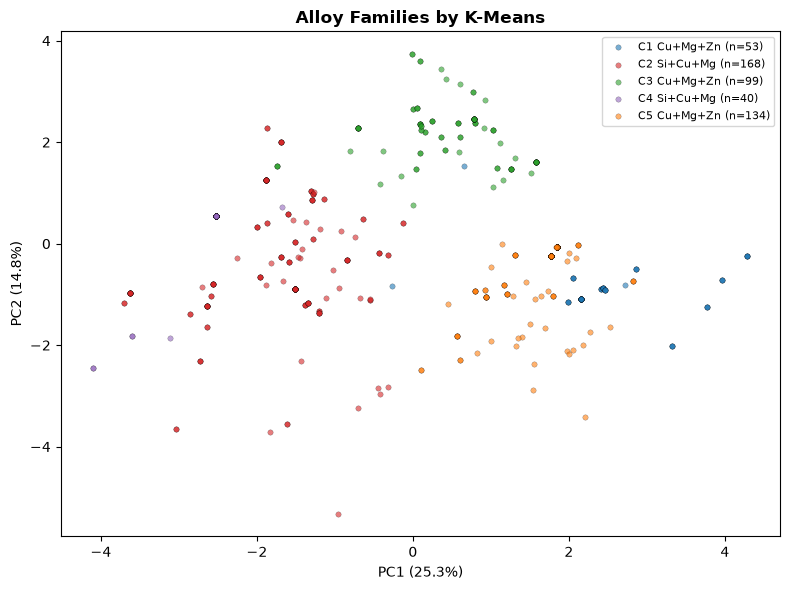

In [3]:
# Figure 1: PCA of clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)
colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e']

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(K):
    mask = df_all['cluster'] == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[c], s=15, alpha=0.6,
              edgecolors='k', linewidth=0.2,
              label=f'C{c+1} {clusters[c]["label"]} (n={mask.sum()})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Alloy Families by K-Means', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'cluster_pca.pdf'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

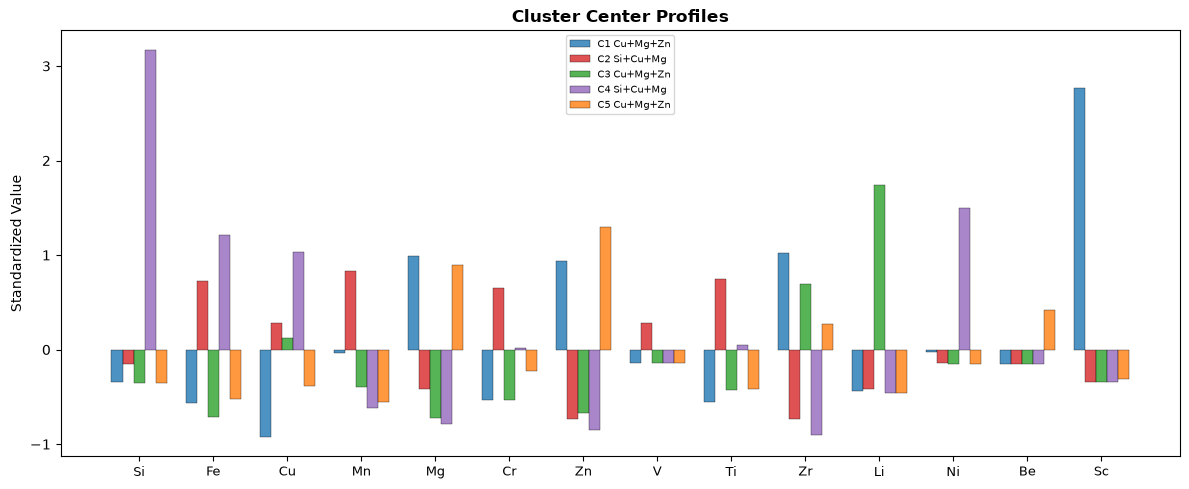

In [4]:
# Figure 2: Cluster center profiles
centers = km.cluster_centers_
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ELEMENTS))
width = 0.15
for c in range(K):
    ax.bar(x + c*width, centers[c], width, color=colors[c], alpha=0.8,
           edgecolor='k', linewidth=0.3, label=f'C{c+1} {clusters[c]["label"]}')
ax.set_xticks(x + width*2)
ax.set_xticklabels(ELEMENTS, fontsize=9)
ax.set_ylabel('Standardized Value')
ax.set_title('Cluster Center Profiles', fontsize=12, fontweight='bold')
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'cluster_profiles.pdf'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## Step 2 — Per-Cluster LHS + Champion + Pareto

Bounds: cluster 5%-95% percentile, overridden by domain knowledge:
- **Sc <= 0.3%**: commercial viability (C1 data: Sc-YS corr = -0.095)
- **Fe <= 0.5%**: wrought alloy impurity limit
- **Tage >= 100C**: artificial ageing only (exclude natural ageing at 25-30C)

Post-prediction filters:
- Al >= 85%, Tage < Tsol - 30, UTS >= YS, **YS >= 250 MPa**
- YS >= 250 MPa: exclude trivial dilute/under-aged solutions
- Best Balance = Euclidean distance to utopia point (max YS, UTS, El)
- N_LHS = 5000 per cluster

In [6]:
all_pareto = []
cluster_pareto = {}

Tsol_idx = len(ELEMENTS)
Tage_idx = len(ELEMENTS) + 1
tage_idx = len(ELEMENTS) + 2

# --- Domain-knowledge constraint overrides ---
# Sc <= 0.3%: commercial viability; C1 data shows Sc-YS corr = -0.095 (no benefit >0.3%)
SC_IDX = ELEMENTS.index('Sc')
SC_CAP = 0.003
# Fe <= 0.5%: wrought alloy impurity limit
FE_IDX = ELEMENTS.index('Fe')
FE_CAP = 0.005
# Tage >= 100 C: artificial ageing only (exclude natural ageing at 25-30 degC)
TAGE_MIN = 100

for c in range(K):
    label = clusters[c]['label']
    cid = clusters[c]['id']
    cdf = clusters[c]['data']
    print()
    print('=' * 50)
    print(f'  C{cid}: {label} ({clusters[c]["n"]} samples)')
    print('=' * 50)

    # Bounds: cluster 5%-95% percentile
    lbs, ubs = [], []
    for e in ELEMENTS:
        lbs.append(np.percentile(cdf[e], 5))
        ubs.append(np.percentile(cdf[e], 95))
    for p in PROCESS_COLS:
        lbs.append(np.percentile(cdf[p], 5))
        ubs.append(np.percentile(cdf[p], 95))
    lbs_arr = np.array(lbs)
    ubs_arr = np.array(ubs)

    # Apply domain-knowledge caps
    ubs_arr[SC_IDX] = min(ubs_arr[SC_IDX], SC_CAP)
    ubs_arr[FE_IDX] = min(ubs_arr[FE_IDX], FE_CAP)
    lbs_arr[Tage_idx] = max(lbs_arr[Tage_idx], TAGE_MIN)

    # LHS
    d = len(ALL_VARS)
    sampler = LatinHypercube(d=d, seed=42)
    X_lhs = lbs_arr + (ubs_arr - lbs_arr) * sampler.random(n=N_LHS)

    # Filter: Al>=85%, Tage<Tsol-30
    al = 1.0 - X_lhs[:, :len(ELEMENTS)].sum(axis=1)
    ok = (al >= 0.85) & (X_lhs[:, Tage_idx] < X_lhs[:, Tsol_idx] - 30)
    X_v = X_lhs[ok]
    print(f'  Valid: {X_v.shape[0]}/{N_LHS}')

    # Batch predict
    BATCH = 200
    n_v = X_v.shape[0]
    n_b = int(np.ceil(n_v / BATCH))
    YS = np.zeros(n_v)
    UTS = np.zeros(n_v)
    EL = np.zeros(n_v)
    for bi in range(n_b):
        i0 = bi * BATCH
        i1 = min((bi + 1) * BATCH, n_v)
        df_b = pd.DataFrame(X_v[i0:i1, :len(ELEMENTS)], columns=ELEMENTS)
        df_b['Tsol'] = X_v[i0:i1, Tsol_idx]
        df_b['Tage'] = X_v[i0:i1, Tage_idx]
        df_b['tage'] = X_v[i0:i1, tage_idx]
        Xe_df, _, _, _ = featurize_metal_all(
            df_b, mass_frac_cols=ELEMENTS, process_cols=PROCESS_COLS,
            groups=['composition','precipitation','process','physics'],
            add_al_balance=True)
        Xe = Xe_df.values
        en = list(Xe_df.columns)
        for ti, t in enumerate(TARGET_COLS):
            pkg = champion[t]
            fn = pkg['features']
            rf = [x for x in fn if x in RAW_COLS_ALL]
            ef = [x for x in fn if x not in RAW_COLS_ALL]
            parts = []
            if rf:
                parts.append(df_b[rf].values.astype(float))
            if ef:
                idx = [en.index(x) for x in ef if x in en]
                if idx:
                    parts.append(Xe[:, idx])
            Xt = np.column_stack(parts) if len(parts) > 1 else parts[0]
            Xs = pkg['scaler'].transform(Xt)
            yp = pkg['model'].predict(Xs)
            if ti == 0:
                YS[i0:i1] = yp
            elif ti == 1:
                UTS[i0:i1] = yp
            else:
                EL[i0:i1] = yp

    # UTS >= YS
    phys = UTS >= YS
    YS = YS[phys]
    UTS = UTS[phys]
    EL = EL[phys]
    X_v = X_v[phys]
    print(f'  UTS>=YS: {phys.sum()}/{n_v}')

    # YS >= 250 MPa: exclude trivial dilute/under-aged solutions
    strong = YS >= 250
    YS = YS[strong]
    UTS = UTS[strong]
    EL = EL[strong]
    X_v = X_v[strong]
    print(f'  YS>=250: {strong.sum()}/{phys.sum()}')

    if X_v.shape[0] < 5:
        print(f'  Too few solutions ({X_v.shape[0]}), skip cluster')
        continue

    # Pareto
    obj = np.column_stack([-YS, -UTS, -EL])

    def pareto_mask(costs):
        eff = np.ones(costs.shape[0], dtype=bool)
        for i in range(costs.shape[0]):
            if not eff[i]:
                continue
            dominated = (np.all(costs[eff] <= costs[i], axis=1) &
                        np.any(costs[eff] < costs[i], axis=1))
            eff[eff] = ~dominated
            eff[i] = True
        return eff

    p = pareto_mask(obj)
    print(f'  Pareto: {p.sum()}/{X_v.shape[0]}')

    pi = np.where(p)[0]
    if len(pi) == 0:
        print('  No Pareto solutions for this cluster')
        continue

    # Representative points
    bs = pi[np.argmax(YS[pi])]   # Max Strength
    be = pi[np.argmax(EL[pi])]   # Max Ductility

    # Best Balance = closest to utopia (max YS, max UTS, max El)
    utopia = np.array([YS[pi].max(), UTS[pi].max(), EL[pi].max()])
    nadir = np.array([YS[pi].min(), UTS[pi].min(), EL[pi].min()])
    rng = np.where(utopia - nadir > 1e-6, utopia - nadir, 1.0)
    obj_vals = np.column_stack([YS[pi], UTS[pi], EL[pi]])
    dist_to_utopia = np.sqrt(np.sum(((utopia - obj_vals) / rng)**2, axis=1))
    bb = pi[np.argmin(dist_to_utopia)]

    for xlabel, idx in [('Max Strength', bs), ('Best Balance', bb), ('Max Ductility', be)]:
        print()
        print(f'  [{xlabel}]')
        for ei, e in enumerate(ELEMENTS):
            print(f'    {e} = {X_v[idx, ei]*100:.2f}%')
        print(f'    Tsol = {X_v[idx, Tsol_idx]:.0f} C')
        print(f'    Tage = {X_v[idx, Tage_idx]:.0f} C')
        print(f'    tage = {X_v[idx, tage_idx]:.1f} h')
        print(f'    YS  = {YS[idx]:.0f} MPa')
        print(f'    UTS = {UTS[idx]:.0f} MPa')
        print(f'    El  = {EL[idx]:.1f} %')

    cluster_pareto[c] = {
        'YS': YS, 'UTS': UTS, 'EL': EL, 'p': p,
        'label': label, 'cid': cid,
        'best_str': bs, 'best_bal': bb, 'best_el': be
    }

    for i in pi:
        row = {}
        for ei, e in enumerate(ELEMENTS):
            row[e] = float(X_v[i, ei])
        for pi2, pp in enumerate(PROCESS_COLS):
            row[pp] = float(X_v[i, len(ELEMENTS) + pi2])
        row['YS_pred'] = float(YS[i])
        row['UTS_pred'] = float(UTS[i])
        row['El_pred'] = float(EL[i])
        row['cluster'] = int(c)
        row['cluster_label'] = label
        row['cluster_id'] = int(cid)
        all_pareto.append(row)

print()
print(f'Total: {len(all_pareto)} Pareto solutions collected')


  C1: Cu+Mg+Zn (53 samples)
  Valid: 5000/5000
  UTS>=YS: 4958/5000
  YS>=250: 4958/4958
  Pareto: 55/4958

  [Max Strength]
    Si = 0.12%
    Fe = 0.08%
    Cu = 0.89%
    Mn = 0.17%
    Mg = 2.57%
    Cr = 0.00%
    Zn = 6.74%
    V = 0.00%
    Ti = 0.00%
    Zr = 0.25%
    Li = 0.00%
    Ni = 0.00%
    Be = 0.00%
    Sc = 0.25%
    Tsol = 466 C
    Tage = 140 C
    tage = 20.6 h
    YS  = 572 MPa
    UTS = 612 MPa
    El  = 5.2 %

  [Best Balance]
    Si = 0.02%
    Fe = 0.15%
    Cu = 1.32%
    Mn = 0.18%
    Mg = 2.28%
    Cr = 0.00%
    Zn = 7.18%
    V = 0.00%
    Ti = 0.00%
    Zr = 0.09%
    Li = 0.00%
    Ni = 0.00%
    Be = 0.00%
    Sc = 0.23%
    Tsol = 479 C
    Tage = 110 C
    tage = 1.9 h
    YS  = 420 MPa
    UTS = 602 MPa
    El  = 13.5 %

  [Max Ductility]
    Si = 0.13%
    Fe = 0.12%
    Cu = 2.06%
    Mn = 0.13%
    Mg = 1.98%
    Cr = 0.00%
    Zn = 7.38%
    V = 0.00%
    Ti = 0.00%
    Zr = 0.06%
    Li = 0.00%
    Ni = 0.00%
    Be = 0.00%
    Sc = 0.23%
  

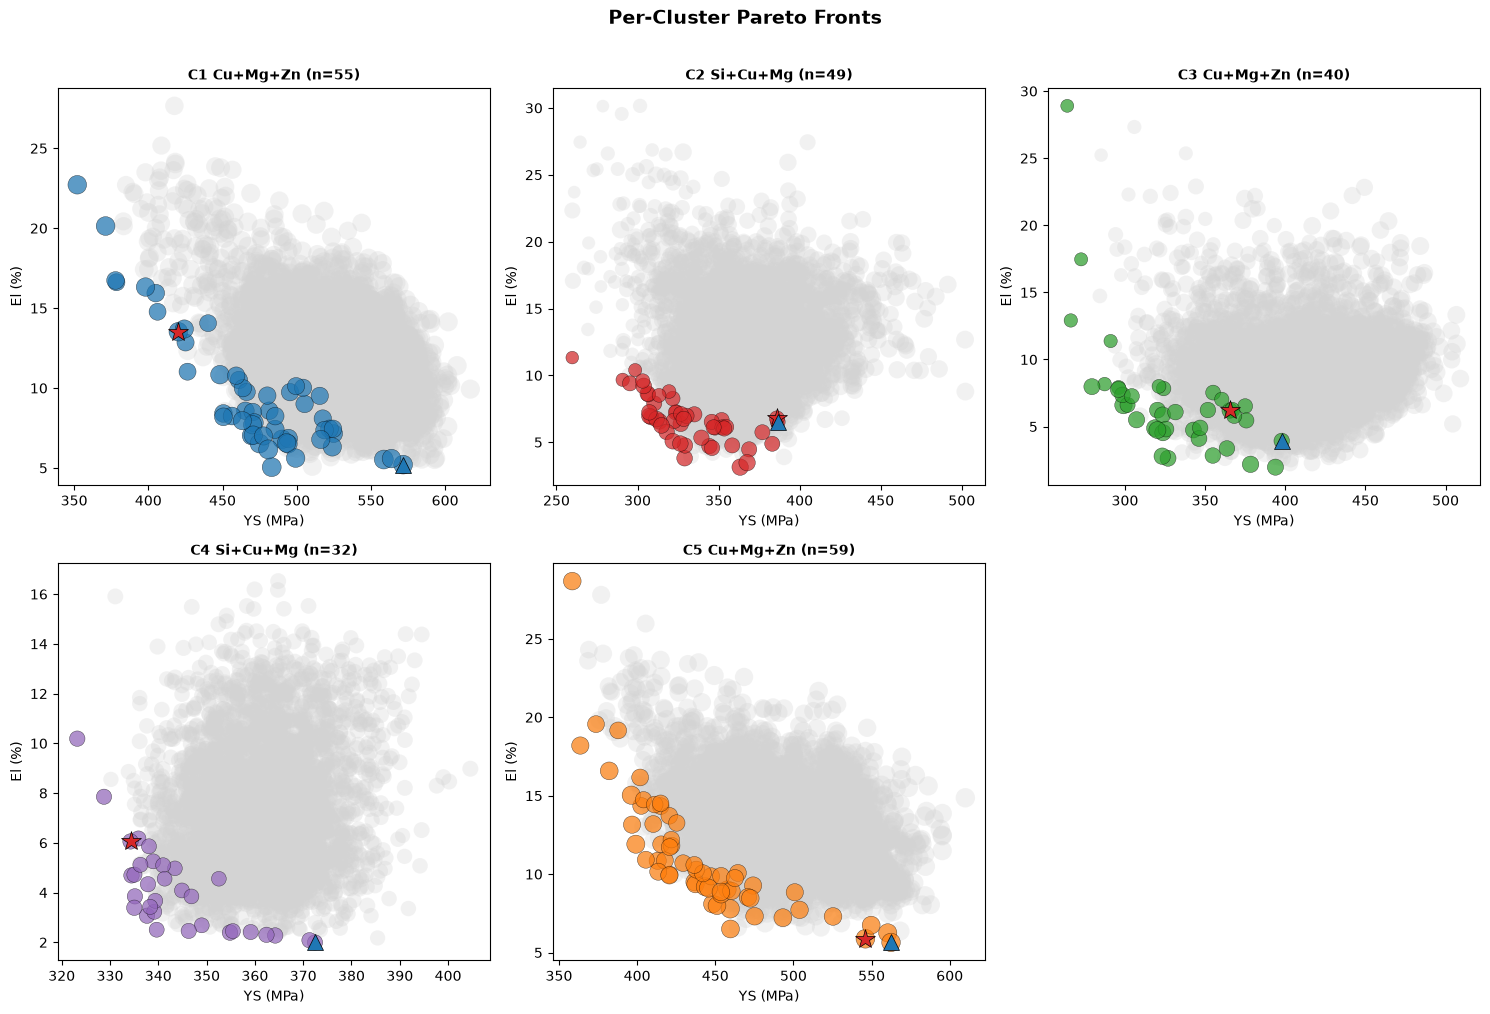

In [7]:
# Figure 3: Per-cluster Pareto bubble charts
n_plots = len(cluster_pareto)
if n_plots == 0:
    print('No clusters survived.')
else:
    n_cols = min(n_plots, 3)
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    for ci, c in enumerate(sorted(cluster_pareto.keys())):
        ax = axes[ci]
        d = cluster_pareto[c]
        ax.scatter(d['YS'], d['EL'], s=d['UTS'] * 0.3, c='lightgray', alpha=0.3, edgecolors='none')
        ax.scatter(d['YS'][d['p']], d['EL'][d['p']], s=d['UTS'][d['p']] * 0.3,
                  c=colors[ci], alpha=0.7, edgecolors='k', linewidth=0.3)
        ax.plot(d['YS'][d['best_bal']], d['EL'][d['best_bal']], '*',
                color='#d62728', ms=15, mec='k', mew=0.5, zorder=10)
        ax.plot(d['YS'][d['best_str']], d['EL'][d['best_str']], '^',
                color='#1f77b4', ms=12, mec='k', mew=0.5, zorder=10)
        ax.set_xlabel('YS (MPa)')
        ax.set_ylabel('El (%)')
        ax.set_title(f'C{d["cid"]} {d["label"]} (n={d["p"].sum()})', fontsize=10, fontweight='bold')
    for ax in axes[n_plots:]:
        ax.set_visible(False)
    fig.suptitle('Per-Cluster Pareto Fronts', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, 'cluster_pareto_grid.pdf'), dpi=SAVE_DPI, bbox_inches='tight')
    plt.show()

In [9]:
# Save Pareto solutions
df_out = pd.DataFrame(all_pareto)
df_out.to_csv(os.path.join(OPT_DIR, 'cluster_pareto.csv'), index=False)
print(f'Saved {len(df_out)} Pareto solutions from {df_out["cluster"].nunique()} clusters')
for c in sorted(df_out['cluster'].unique()):
    sdf = df_out[df_out['cluster'] == c]
    cid = sdf['cluster_id'].iloc[0]
    label = sdf['cluster_label'].iloc[0]
    print(f'  C{cid} ({label}): {len(sdf)} solutions, '
          f'YS={sdf["YS_pred"].min():.0f}-{sdf["YS_pred"].max():.0f}, '
          f'El={sdf["El_pred"].min():.1f}-{sdf["El_pred"].max():.1f}%')

# Also save full training data with cluster labels for N08 validation
# (same fillna(0) + KMeans random_state=42 as used throughout N06)
df_all.to_csv(os.path.join(OPT_DIR, 'training_clustered.csv'), index=False)
print(f'\nSaved clustered training data ({len(df_all)} rows) to training_clustered.csv')
print('Next: 07_cross_cluster_analysis.ipynb')

Saved 235 Pareto solutions from 5 clusters
  C1 (Cu+Mg+Zn): 55 solutions, YS=352-572, El=5.1-22.7%
  C2 (Si+Cu+Mg): 49 solutions, YS=260-386, El=3.1-11.3%
  C3 (Cu+Mg+Zn): 40 solutions, YS=264-398, El=2.0-28.9%
  C4 (Si+Cu+Mg): 32 solutions, YS=323-372, El=2.0-10.2%
  C5 (Cu+Mg+Zn): 59 solutions, YS=359-562, El=5.6-28.7%

Saved clustered training data (494 rows) to training_clustered.csv
Next: 07_cross_cluster_analysis.ipynb
